In [93]:
import torch
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math
import torch.nn.functional as F

def split_with_overlap(img, h, w, stride_h=None, stride_w=None, 
                       padding_mode='reflect', return_padding=True):
    """
    带重叠的切分（滑动窗口），自动 padding 到能被 h,w 整除的最小尺寸
    
    参数:
        img: 4维张量 (B, C, H, W)
        h, w: 每个 patch 的高度和宽度
        stride_h, stride_w: 滑动步长，None 表示无重叠（等于 h,w）
        padding_mode: 'reflect'(反射), 'replicate'(复制), 'constant'(常数0), 'circular'(循环)
        return_padding: 是否返回 padding 信息（用于后续合并）
    
    返回:
        patches: 6维张量 (B, n_h, n_w, C, h, w)
        pad_info: (如果 return_padding=True) 包含 padding 信息的字典
    """
    B, C, H, W = img.shape
    stride_h = stride_h or h
    stride_w = stride_w or w
    
    # 计算需要 padding 的尺寸
    # 公式: n_patches = ceil((size - patch_size) / stride) + 1
    # 需要的总尺寸: (n_patches - 1) * stride + patch_size
    
    # 计算垂直方向需要的 patches 数量和总高度
    if H <= h:
        n_h = 1
        needed_h = h
    else:
        n_h = math.ceil((H - h) / stride_h) + 1
        needed_h = (n_h - 1) * stride_h + h
    
    # 计算水平方向
    if W <= w:
        n_w = 1
        needed_w = w
    else:
        n_w = math.ceil((W - w) / stride_w) + 1
        needed_w = (n_w - 1) * stride_w + w
    
    # 计算 padding
    pad_h = needed_h - H
    pad_w = needed_w - W
    
    # 对称 padding（优先底部和右侧）
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left
    
    # 应用 padding
    if pad_h > 0 or pad_w > 0:
        img_padded = F.pad(img, (pad_left, pad_right, pad_top, pad_bottom), 
                          mode=padding_mode)
    else:
        img_padded = img
    
    # 使用 unfold 提取 patches
    patches = img_padded.unfold(2, h, stride_h).unfold(3, w, stride_w)
    patches = patches.permute(0, 2, 3, 1, 4, 5)  # (B, n_h, n_w, C, h, w)
    
    if return_padding:
        pad_info = {
            'original_size': (H, W),
            'padded_size': (needed_h, needed_w),
            'padding': (pad_top, pad_bottom, pad_left, pad_right),
            'n_patches': (n_h, n_w),
            'stride': (stride_h, stride_w),
            'patch_size': (h, w)
        }
        return patches, pad_info
    
    return patches

def create_gaussian_window(h, w, sigma_factor=4.0, device='cpu'):
    """
    创建二维高斯权重窗口
    
    参数:
        h, w: 窗口高度和宽度
        sigma_factor: 标准差系数，sigma = size / sigma_factor，越小边缘越锐利
    """
    # 创建坐标网格，中心为原点
    y = torch.arange(h, device=device, dtype=torch.float32) - (h - 1) / 2
    x = torch.arange(w, device=device, dtype=torch.float32) - (w - 1) / 2
    y, x = torch.meshgrid(y, x, indexing='ij')
    
    # 计算高斯分布
    sigma_y = h / sigma_factor
    sigma_x = w / sigma_factor
    gaussian = torch.exp(-(y**2 / (2 * sigma_y**2) + x**2 / (2 * sigma_x**2)))
    
    # 归一化到 [0, 1]
    return gaussian/gaussian.max()


def merge_with_padding(patches, pad_info, mode='mean', gaussian_sigma=4.0):
    """
    将带 padding 切分的 patches 合并回原图尺寸
    
    参数:
        patches: (B, n_h, n_w, C, h, w) 或 (B, num_patches, C, h, w)
        pad_info: padding 信息字典
        mode: 'mean'(平均), 'sum'(求和), 'gaussian'(高斯加权)
        gaussian_sigma: 高斯分布的 sigma 系数，默认 4.0
    """
    B = patches.shape[0]
    C = patches.shape[-3]
    H, W = pad_info['original_size']
    needed_h, needed_w = pad_info['padded_size']
    pad_top, pad_bottom, pad_left, pad_right = pad_info['padding']
    stride_h, stride_w = pad_info['stride']
    h, w = pad_info['patch_size']
    n_h, n_w = pad_info['n_patches']
    device = patches.device
    
    # 统一为 5 维: (B, num_patches, C, h, w)
    if patches.dim() == 6:
        patches = patches.reshape(B, n_h * n_w, C, h, w)
    
    num_patches = patches.shape[1]
    
    # 准备权重
    if mode == 'gaussian':
        # 创建高斯权重窗口 (h, w)
        weight_window = create_gaussian_window(h, w, gaussian_sigma, device)
        # 扩展到 (1, 1, 1, h, w) 用于广播
        weight_window = weight_window.view(1, 1, 1, h, w)
        # 应用到所有 patches: (B, num_patches, C, h, w) * (1, 1, 1, h, w)
        weighted_patches = patches * weight_window
    else:
        weighted_patches = patches
    
    # reshape 为 F.fold 格式: (B, C*h*w, num_patches)
    patches_flat = weighted_patches.permute(0, 2, 3, 4, 1).reshape(B, C * h * w, num_patches)
    
    # 使用 F.fold 合并
    merged_padded = F.fold(
        patches_flat,
        output_size=(needed_h, needed_w),
        kernel_size=(h, w),
        stride=(stride_h, stride_w)
    )
    
    # 计算权重和（用于归一化）
    if mode == 'mean':
        ones = torch.ones_like(patches_flat)
        norm = F.fold(
            ones,
            output_size=(needed_h, needed_w),
            kernel_size=(h, w),
            stride=(stride_h, stride_w)
        )
        merged_padded = merged_padded / norm.clamp(min=1)
        
    elif mode == 'gaussian':
        # 高斯模式：需要计算权重图的 fold 和
        # 创建与 patches_flat 对应权重的张量
        # weight_window: (h, w) -> 扩展到 (B, C, h, w, num_patches) -> (B, C*h*w, num_patches)
        weight_expanded = weight_window.view(1, 1, h, w, 1).expand(B, C, -1, -1, num_patches)
        weight_flat = weight_expanded.reshape(B, C * h * w, num_patches)
        
        # fold 权重和
        weight_sum = F.fold(
            weight_flat,
            output_size=(needed_h, needed_w),
            kernel_size=(h, w),
            stride=(stride_h, stride_w)
        )
        
        # 归一化：加权求和 / 权重和
        merged_padded = merged_padded / weight_sum.clamp(min=1e-8)
    
    # 裁剪掉 padding
    merged = merged_padded[:, :, pad_top:pad_top+H, pad_left:pad_left+W]
    
    return merged

### Test image splitting

torch.Size([1, 3, 288, 288])


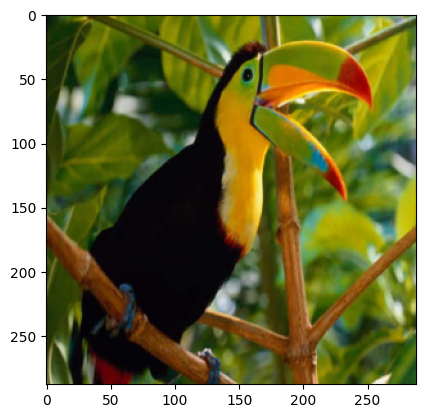

In [94]:
img = torch.from_numpy(plt.imread('/8T1/dataset/SRDataset/ImageSR/test/Set5/HR/img_002.png')).unsqueeze(0).permute(0,3,1,2)
print(img.shape)
plt.imshow(plt.imread('/8T1/dataset/SRDataset/ImageSR/test/Set5/HR/img_002.png'))

In [108]:
splited_img, padding_info = split_with_overlap(img, 64, 64, stride_h=64, stride_w=64, padding_mode='constant')
print(splited_img.shape)

torch.Size([1, 5, 5, 3, 64, 64])


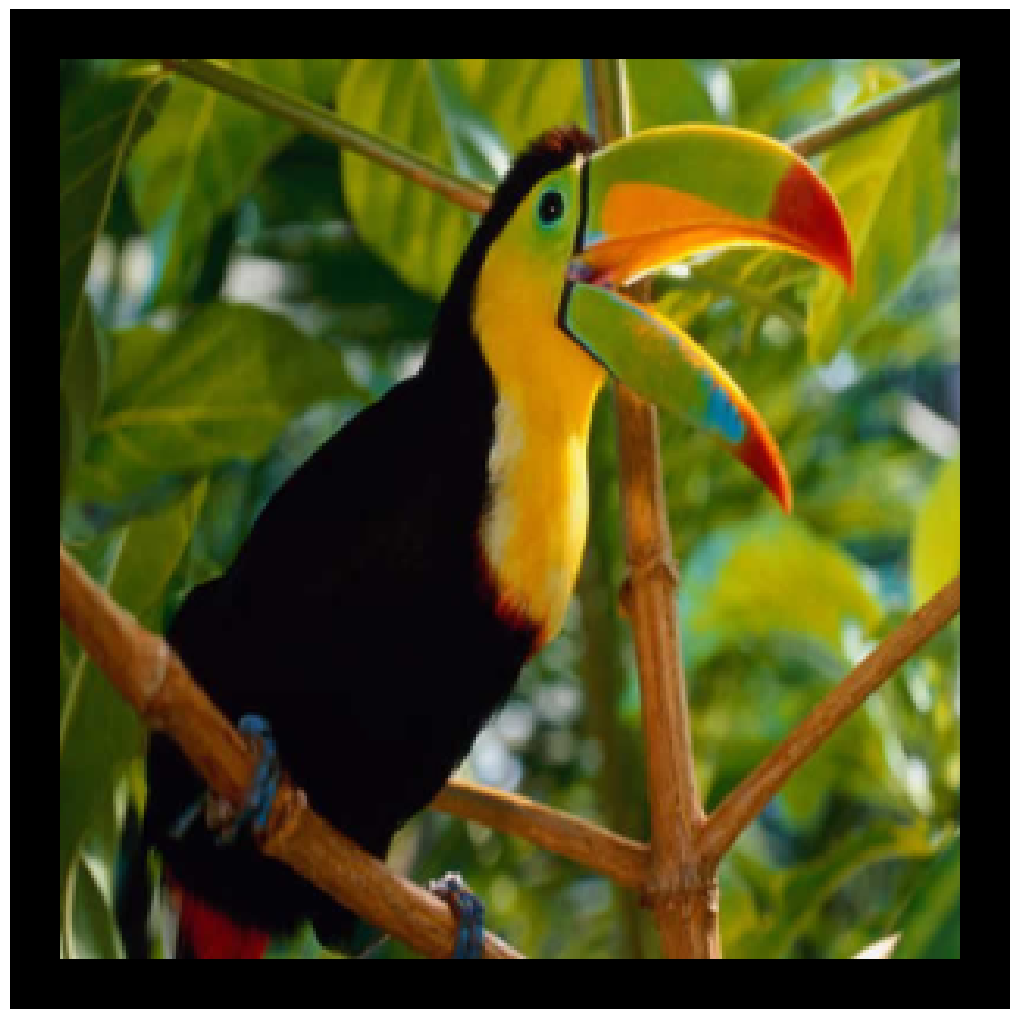

In [106]:
plt.figure(figsize=(10,10))
b, nh, nw, c, h, w = splited_img.shape
for i in range(nh):
    for j in range(nw):
        plt.subplot(nh,nw, i*nh+j+1)
        plt.xticks([])
        plt.yticks([])
        plt.subplots_adjust(
        left=0,      # 左边距
        right=1,     # 右边距
        bottom=0,    # 下边距
        top=1,       # 上边距
        wspace=0,    # 水平间距
        hspace=0     # 垂直间距
            )
        plt.imshow(splited_img[0,i,j,...].permute(1,2,0))

### Test merged iamges

torch.Size([1, 3, 288, 288])


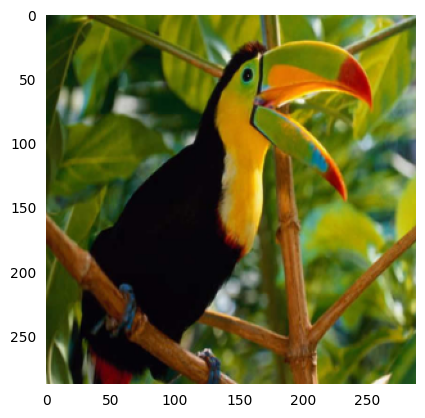

In [109]:
merged_img = merge_with_padding(splited_img, padding_info, mode='mean')
print(merged_img.shape)
plt.imshow(merged_img[0,...].permute(1,2,0))

### Test error

In [91]:
print(merged_img.shape)
print(img.shape)
torch.sum((merged_img-img)**2)

torch.Size([1, 3, 288, 288])
torch.Size([1, 3, 288, 288])


tensor(0.)

In [114]:
a = (torch.randn_like(img).to(img.device) < 0) * 2.0 - 1.0
torch.unique(a)

tensor([-1.,  1.])